<a href="https://colab.research.google.com/github/jazmynehisole/FYP_Project_25_26/blob/main/FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/Revisions for Infection Dataset/All THRs.csv")
print(df.columns)
print(df.head())

Index(['Surgical Event: Operation Date', 'Surgical Staff: Consultant',
       'Surgical Staff: Anaesthetist', 'Consultant Name', 'Procedure Name',
       'Procedure Side', 'Surgical Event: All Procedures', 'Patient: Gender',
       'Date of Birth', 'InPatient Event: Age at Time of Event',
       'Surgical Event: ASA Score', 'Patient: Date of Death',
       'Surgical Event: Anaesthetic', 'Surgical Event: Anaesthetic.1',
       'InPatient Event: Days In (Total)', 'InPatient Event: Admission Date',
       'InPatient Event: Discharge Date', 'Revision Procedure',
       'Revision side', 'Revision same side', 'Revision side.1',
       'Time between Revision and Primary (Days)', 'Indication for Revision',
       'Unnamed: 23', 'Revision Surgeon', 'Revision Surgeon.1',
       'Revision Surgeon Same', 'Age at Revision', 'ASA at Revision',
       'Surgical Event: Anaesthetic at Revision', 'LOS of Revision',
       'In-patient Admission Date Revision',
       'In-patient Discharge Date Revision',

STANDALONE

In [38]:
# libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [39]:
# load data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/Revisions for Infection Dataset/All THRs.csv")
df.columns = df.columns.str.strip()

# target
df['PJI'] = df['Indication for Revision'].astype(str).str.contains(
    'infection', case=False, na=False
).astype(int)

# feature set
features = [
    'InPatient Event: Age at Time of Event',
    'Patient: Gender',
    'Surgical Event: ASA Score',
    'Procedure Name',
    'Procedure Side'
]

In [40]:
# data cleaning
df_model = df[features + ['PJI']].copy()

# replace text placeholders
df_model = df_model.replace(['Unknown', 'unknown', 'nan', 'NaN', ''], np.nan)

# drop missing rows
df_model = df_model.dropna()

print("Final shape:", df_model.shape)
print("Class balance:\n", df_model['PJI'].value_counts())

Final shape: (623, 6)
Class balance:
 PJI
0    620
1      3
Name: count, dtype: int64


In [41]:
# x and y defined
X = df_model[features]
y = df_model['PJI']

# feature types
numeric_features = [
    'InPatient Event: Age at Time of Event',
    'Surgical Event: ASA Score'
]

categorical_features = [
    'Patient: Gender',
    'Procedure Name',
    'Procedure Side'
]

In [42]:
# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Logistic Regression

In [43]:
lgmodel = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lgmodel.fit(X_train, y_train)

y_pred = lgmodel.predict(X_test)
y_proba = lgmodel.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.79      0.88       124
           1       0.04      1.00      0.07         1

    accuracy                           0.79       125
   macro avg       0.52      0.90      0.48       125
weighted avg       0.99      0.79      0.88       125

[[98 26]
 [ 0  1]]
AUC: 0.8629032258064516


Random Forest

In [44]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight='balanced'
    ))
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

Random Forest
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       124
           1       0.00      0.00      0.00         1

    accuracy                           0.99       125
   macro avg       0.50      0.50      0.50       125
weighted avg       0.98      0.99      0.99       125

Confusion Matrix:
[[124   0]
 [  1   0]]
AUC: 0.45161290322580644


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM

In [45]:
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

print("SVM")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

SVM
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       124
           1       0.33      1.00      0.50         1

    accuracy                           0.98       125
   macro avg       0.67      0.99      0.75       125
weighted avg       0.99      0.98      0.99       125

Confusion Matrix:
[[122   2]
 [  0   1]]
AUC: 0.0


XGBoost

In [46]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

XGBoost
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       124
           1       0.00      0.00      0.00         1

    accuracy                           0.99       125
   macro avg       0.50      0.50      0.50       125
weighted avg       0.98      0.99      0.99       125

Confusion Matrix:
[[124   0]
 [  1   0]]
AUC: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    "Accuracy": [
        0.79,
        0.99,
        0.98,
        0.99
    ],
    "Precision (PJI)":[
        0.04,
        0.00,
        0.33,
        0.00
    ],
    "Recall (PJI)":[
        1.00,
        0.00,
        1.00,
        0.00
    ],
    "F1-score":[
        0.07,
        0.00,
        0.50,
        0.00
    ],
    "AUC":[
        0.86,
        0.45,
        0.00,
        0.50
    ]
})

print("Standalone Results")
print(results.sort_values(by="AUC", ascending=False))

Standalone Results
                 Model  Accuracy  Precision (PJI)  Recall (PJI)  F1-score  \
0  Logistic Regression      0.79             0.04           1.0      0.07   
3              XGBoost      0.99             0.00           0.0      0.00   
1        Random Forest      0.99             0.00           0.0      0.00   
2                  SVM      0.98             0.33           1.0      0.50   

    AUC  
0  0.86  
3  0.50  
1  0.45  
2  0.00  


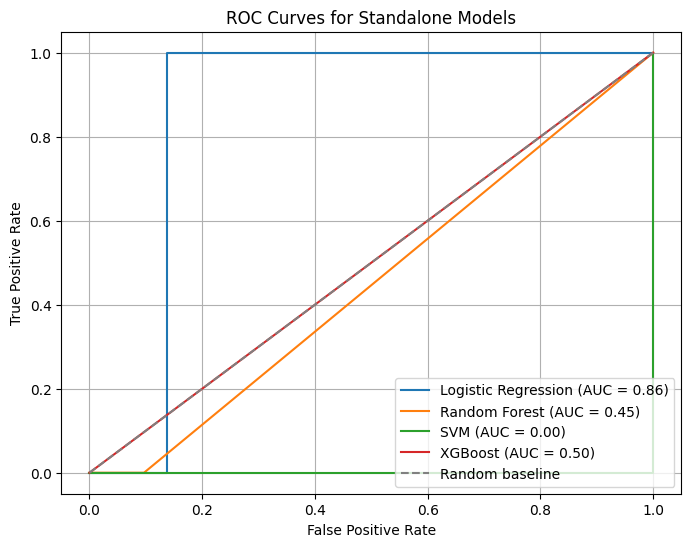

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# raw features
feature_cols = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score",
    "Patient: Gender",
    "Procedure Name",
    "Procedure Side"
]

df_model = df[feature_cols + ["PJI"]].dropna().copy()

X_raw = df_model[feature_cols]
y = df_model["PJI"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ROC
models = {
    "Logistic Regression": lgmodel,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "XGBoost": xgb_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_raw)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_raw, y_proba)
    auc_score = roc_auc_score(y_test_raw, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Standalone Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

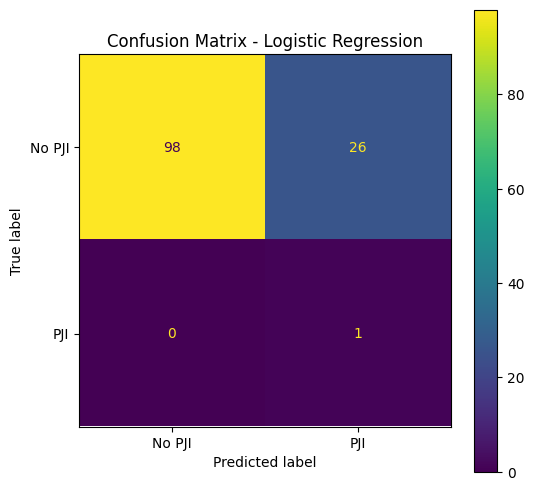

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = lgmodel.predict(X_test_raw)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No PJI", "PJI"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

SMOTE

In [50]:
from sklearn.preprocessing import OrdinalEncoder

from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Logistic Regression SMOTE

In [51]:
from sklearn.preprocessing import OrdinalEncoder

from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline


print("Columns:")
print(df.columns.tolist())

print("\nTarget distribution (full dataset):")
print(df['PJI'].value_counts(dropna=False))

features = [
    'InPatient Event: Age at Time of Event',
    'Patient: Gender',
    'Surgical Event: ASA Score',
    'Procedure Name',
    'Procedure Side'
]

df_model = df[features + ['PJI']].copy()
df_model = df_model.replace(['Unknown', 'unknown', 'nan', 'NaN', ''], np.nan)
df_model = df_model.dropna()

print("\nShape after cleaning:", df_model.shape)
print("\nTarget distribution (model dataset):")
print(df_model['PJI'].value_counts())

X = df_model[features]
y = df_model['PJI']

class_counts = y.value_counts()
minority_count = class_counts.min()

print("\nClass counts:")
print(class_counts)

if minority_count < 2:
    raise ValueError(
        "There are fewer than 2 minority-class cases. "
        "SMOTE/SMOTENC cannot be applied reliably. "
        "You need more positive cases or a different target definition."
    )
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain class distribution before SMOTE:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

numeric_features = [
    'InPatient Event: Age at Time of Event',
    'Surgical Event: ASA Score'
]

categorical_features = [
    'Patient: Gender',
    'Procedure Name',
    'Procedure Side'
]

preprocessor_for_smote = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

categorical_indices = [len(numeric_features) + i for i in range(len(categorical_features))]
train_minority_count = y_train.value_counts().min()
k_neighbors = min(5, train_minority_count - 1)

if k_neighbors < 1:
    raise ValueError(
        "Not enough minority cases in the training set for SMOTENC. "
        "Try a different split, more positive cases, or no SMOTE."
    )

smote = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42,
    k_neighbors=k_neighbors
)

classifier = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

LGSmodel = ImbPipeline(steps=[
    ('preprocessor', preprocessor_for_smote),
    ('smote', smote),
    ('classifier', classifier)
])

LGSmodel.fit(X_train, y_train)

y_pred = LGSmodel.predict(X_test)
y_proba = LGSmodel.predict_proba(X_test)[:, 1]

print("\nLogistic Regression SMOTE:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

X_train_processed = preprocessor_for_smote.fit_transform(X_train)
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

print("\nTraining set size before SMOTE:", X_train.shape[0])
print("Training set size after SMOTE:", X_resampled.shape[0])
print("Resampled class distribution:")
print(pd.Series(y_resampled).value_counts())

Columns:
['Surgical Event: Operation Date', 'Surgical Staff: Consultant', 'Surgical Staff: Anaesthetist', 'Consultant Name', 'Procedure Name', 'Procedure Side', 'Surgical Event: All Procedures', 'Patient: Gender', 'Date of Birth', 'InPatient Event: Age at Time of Event', 'Surgical Event: ASA Score', 'Patient: Date of Death', 'Surgical Event: Anaesthetic', 'Surgical Event: Anaesthetic.1', 'InPatient Event: Days In (Total)', 'InPatient Event: Admission Date', 'InPatient Event: Discharge Date', 'Revision Procedure', 'Revision side', 'Revision same side', 'Revision side.1', 'Time between Revision and Primary (Days)', 'Indication for Revision', 'Unnamed: 23', 'Revision Surgeon', 'Revision Surgeon.1', 'Revision Surgeon Same', 'Age at Revision', 'ASA at Revision', 'Surgical Event: Anaesthetic at Revision', 'LOS of Revision', 'In-patient Admission Date Revision', 'In-patient Discharge Date Revision', 'Patient: Date of Death.1', 'PJI']

Target distribution (full dataset):
PJI
0    628
1      3


SVM SMOTE

In [52]:
print("Indication for Revision values:")
print(df["Indication for Revision"].value_counts(dropna=False).head(30))

df["PJI"] = df["Indication for Revision"].astype(str).str.contains(
    "infection|infected|pji", case=False, na=False
).astype(int)

print("\nTarget distribution:")
print(df["PJI"].value_counts())

features = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score",
    "Patient: Gender",
    "Procedure Side"
]

df_model = df[features + ["PJI"]].dropna()

print("\nShape after cleaning:", df_model.shape)
print("\nTarget distribution after cleaning:")
print(df_model["PJI"].value_counts())

X = df_model.drop("PJI", axis=1)
y = df_model["PJI"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

if y_train.nunique() < 2:
    raise ValueError("Training set contains only one class. Check target definition.")

minority_count = y_train.value_counts().min()
k_neighbors = min(5, minority_count - 1)

if k_neighbors < 1:
    raise ValueError("Not enough minority class samples for SMOTE.")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

svm_Smodel = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_Smodel.fit(X_train_resampled, y_train_resampled)

y_pred = svm_Smodel.predict(X_test_scaled)
y_proba = svm_Smodel.predict_proba(X_test_scaled)[:, 1]

print("\nSVM SMOTE:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_proba))

Indication for Revision values:
Indication for Revision
THR Aseptic Femoral Loosening                                           75
NaN                                                                     57
Adverse Soft Tissue Reaction to Particulate Debris                      39
Unexplained pain                                                        33
THR Aseptic Acetabular Loosening                                        25
Further Reason For Revision THR                                         23
Infected Hip Arthroplasty (T84.5)                                       19
Closed Periprosthetic Fracture of the Proximal Femur (THR) (M96.6)      17
Undiagnosed Pain After Hip Arthroplasty (T84.0)                         17
Wear of THR Acetabular Component                                        17
0                                                                       15
Recurrent THR Dislocation (T84.0)                                       14
ARMD                                        

Random Forest SMOTE

In [53]:
df["PJI"] = df["Indication for Revision"].astype(str).str.contains(
    "infection|infected|pji", case=False, na=False
).astype(int)

print("Target distribution:")
print(df["PJI"].value_counts())

features = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score",
    "Patient: Gender",
    "Procedure Side"
]

df_model = df[features + ["PJI"]].dropna()

X = df_model.drop("PJI", axis=1)
y = df_model["PJI"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

rf_Smodel = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf_Smodel.fit(X_train_resampled, y_train_resampled)

y_pred = rf_Smodel.predict(X_test)
y_proba = rf_Smodel.predict_proba(X_test)[:, 1]

print("\nRandom Forest SMOTE:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_proba))

Target distribution:
PJI
0    589
1     42
Name: count, dtype: int64
Before SMOTE: PJI
0    465
1     33
Name: count, dtype: int64
After SMOTE: PJI
1    465
0    465
Name: count, dtype: int64

Random Forest SMOTE:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       117
           1       0.00      0.00      0.00         8

    accuracy                           0.82       125
   macro avg       0.46      0.44      0.45       125
weighted avg       0.87      0.82      0.85       125

Confusion Matrix:
[[103  14]
 [  8   0]]
AUC: 0.36164529914529914


XGBoost SMOTE

In [54]:
df["PJI"] = df["Indication for Revision"].astype(str).str.contains(
    "infection|infected|pji", case=False, na=False
).astype(int)

print("Target distribution:")
print(df["PJI"].value_counts())

features = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score",
    "Patient: Gender",
    "Procedure Side"
]

df_model = df[features + ["PJI"]].dropna()

X = df_model.drop("PJI", axis=1)
y = df_model["PJI"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

xgb_Smodel = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_Smodel.fit(X_train_resampled, y_train_resampled)

y_pred = xgb_Smodel.predict(X_test)
y_proba = xgb_Smodel.predict_proba(X_test)[:, 1]

print("\nXGBoost SMOTE:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_proba))

Target distribution:
PJI
0    589
1     42
Name: count, dtype: int64
Before SMOTE: PJI
0    465
1     33
Name: count, dtype: int64
After SMOTE: PJI
1    465
0    465
Name: count, dtype: int64

XGBoost SMOTE:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       117
           1       0.00      0.00      0.00         8

    accuracy                           0.82       125
   macro avg       0.46      0.44      0.45       125
weighted avg       0.87      0.82      0.85       125

Confusion Matrix:
[[103  14]
 [  8   0]]
AUC: 0.3173076923076923


In [55]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression SMOTE",
        "Random Forest SMOTE",
        "SVM SMOTE",
        "XGBoost SMOTE"
    ],
    "Accuracy": [
        0.58,
        0.82,
        0.70,
        0.82
    ],
    "Precision (PJI)":[
        0.02,
        0.00,
        0.08,
        0.00
    ],
    "Recall (PJI)":[
        1.00,
        0.00,
        1.38,
        0.00
    ],
    "F1-score":[
        0.04,
        0.00,
        0.14,
        0.00
    ],
    "AUC":[
        0.60,
        0.36,
        0.55,
        0.32
    ]
})

print("SMOTE Results")
print(results.sort_values(by="AUC", ascending=False))

SMOTE Results
                       Model  Accuracy  Precision (PJI)  Recall (PJI)  \
0  Logistic Regression SMOTE      0.58             0.02          1.00   
2                  SVM SMOTE      0.70             0.08          1.38   
1        Random Forest SMOTE      0.82             0.00          0.00   
3              XGBoost SMOTE      0.82             0.00          0.00   

   F1-score   AUC  
0      0.04  0.60  
2      0.14  0.55  
1      0.00  0.36  
3      0.00  0.32  


HYBRID MODELS

Logistic Regression x Random Forest

In [56]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

features = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score",
    "Patient: Gender",
    "Procedure Side"
]

df_model = df[features + ["PJI"]].dropna()

X = df_model[features].copy()
y = df_model["PJI"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_features = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score"
]

categorical_features = [
    "Patient: Gender",
    "Procedure Side"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

base_models = [
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
]

meta_model = LogisticRegression(max_iter=1000)

hybrid_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=5
    ))
])

hybrid_model.fit(X_train, y_train)

y_pred = hybrid_model.predict(X_test)
y_proba = hybrid_model.predict_proba(X_test)[:, 1]

print("Logistic Regression x Random Forest")
print(classification_report(y_test, y_pred, zero_division=0))
print("AUC:", roc_auc_score(y_test, y_proba))

Logistic Regression x Random Forest
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       117
           1       0.00      0.00      0.00         8

    accuracy                           0.94       125
   macro avg       0.47      0.50      0.48       125
weighted avg       0.88      0.94      0.91       125

AUC: 0.5715811965811965


XGBoost x SVM

In [57]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", ratio)

base_models = [
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        eval_metric='logloss',
        random_state=42
    ))
]

meta_model = LogisticRegression(max_iter=1000)

svm_xgb_hybrid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=5,
        stack_method='predict_proba'
    ))
])

svm_xgb_hybrid.fit(X_train, y_train)

y_pred = svm_xgb_hybrid.predict(X_test)
y_proba = svm_xgb_hybrid.predict_proba(X_test)[:, 1]

print("XGBoost x SVM:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

scale_pos_weight: 14.090909090909092
XGBoost x SVM:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       117
           1       0.00      0.00      0.00         8

    accuracy                           0.94       125
   macro avg       0.47      0.50      0.48       125
weighted avg       0.88      0.94      0.91       125

Confusion Matrix:
[[117   0]
 [  8   0]]
AUC: 0.6132478632478632


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression x SVM

In [58]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

base_models = [
    ('lr', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    )),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
]

meta_model = LogisticRegression(max_iter=1000)

lr_svm_hybrid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=5,
        stack_method='predict_proba'
    ))
])

lr_svm_hybrid.fit(X_train, y_train)

y_pred = lr_svm_hybrid.predict(X_test)
y_proba = lr_svm_hybrid.predict_proba(X_test)[:, 1]

print("Logistic Regression x SVM:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)

Logistic Regression x SVM:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       117
           1       0.00      0.00      0.00         8

    accuracy                           0.94       125
   macro avg       0.47      0.50      0.48       125
weighted avg       0.88      0.94      0.91       125

Confusion Matrix:
[[117   0]
 [  8   0]]
AUC: 0.5844017094017094


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression x Random Forest",
        "XGBoost x SVM",
        "Logistic Regression x SVM"
    ],
    "Accuracy": [
        0.94,
        0.82,
        0.94
    ],
    "Precision (PJI)":[
        0.00,
        0.00,
        0.00
    ],
    "Recall (PJI)":[
        0.00,
        0.00,
        0.00
    ],
    "F1-score":[
        0.00,
        0.00,
        0.00
    ],
    "AUC":[
        0.57,
        0.61,
        0.58
    ]
})

print("Hybrid Results")
print(results.sort_values(by="AUC", ascending=False))

Hybrid Results
                                 Model  Accuracy  Precision (PJI)  \
1                        XGBoost x SVM      0.82              0.0   
2            Logistic Regression x SVM      0.94              0.0   
0  Logistic Regression x Random Forest      0.94              0.0   

   Recall (PJI)  F1-score   AUC  
1           0.0       0.0  0.61  
2           0.0       0.0  0.58  
0           0.0       0.0  0.57  


HYBRID SMOTES

Logistic Regression x SVM SMOTE

In [60]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import SMOTE

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/Revisions for Infection Dataset/All THRs.csv")
df.columns = df.columns.str.strip()

df["PJI"] = df["Indication for Revision"].astype(str).str.contains(
    "infection|infected|pji", case=False, na=False
).astype(int)

features = [
    "InPatient Event: Age at Time of Event",
    "Surgical Event: ASA Score",
    "Patient: Gender",
    "Procedure Side"
]

df_model = df[features + ["PJI"]].dropna()

X = df_model.drop("PJI", axis=1)
y = df_model["PJI"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
log_model = LogisticRegression(max_iter=1000)

hybrid_model = StackingClassifier(
    estimators=[
        ('svm', svm_model),
        ('log', log_model)
    ],
    final_estimator=LogisticRegression()
)

hybrid_model.fit(X_train_resampled, y_train_resampled)

y_pred = hybrid_model.predict(X_test_scaled)
y_proba = hybrid_model.predict_proba(X_test_scaled)[:, 1]

print("\nLogistic Regression x SVM + SMOTE:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_proba))


Logistic Regression x SVM + SMOTE:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82       117
           1       0.08      0.38      0.14         8

    accuracy                           0.70       125
   macro avg       0.51      0.55      0.48       125
weighted avg       0.89      0.70      0.77       125

Confusion Matrix:
[[84 33]
 [ 5  3]]
AUC: 0.5662393162393162


In [66]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression x SVM SMOTE"
    ],
    "Accuracy": [
        0.70
    ],
    "Precision (PJI)":[
        0.08
    ],
    "Recall (PJI)":[
        0.38
    ],
    "F1-score":[
        0.14
    ],
    "AUC":[
        0.57
    ]
})

print("Hybrid SMOTE Results")
print(results.sort_values(by="AUC", ascending=False))

Hybrid SMOTE Results
                             Model  Accuracy  Precision (PJI)  Recall (PJI)  \
0  Logistic Regression x SVM SMOTE       0.7             0.08          0.38   

   F1-score   AUC  
0      0.14  0.57  


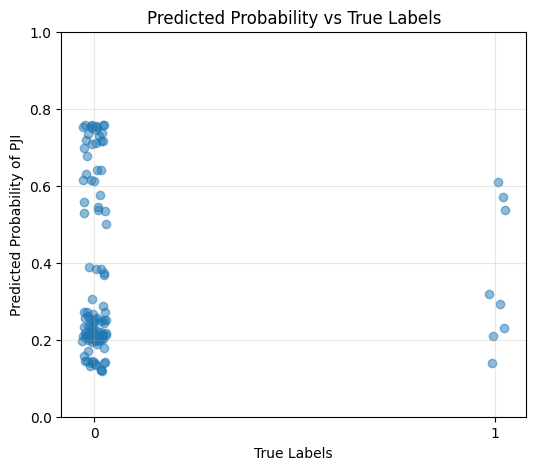

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Predicted probabilities
y_proba = hybrid_model.predict_proba(X_test_scaled)[:, 1]
y_true = np.array(y_test)

# Jitter true labels slightly for visibility
jitter = 0.03
y_true_j = y_true + np.random.uniform(-jitter, jitter, size=len(y_true))

plt.figure(figsize=(6, 5))
plt.scatter(y_true_j, y_proba, alpha=0.5)

plt.xlabel("True Labels")
plt.ylabel("Predicted Probability of PJI")
plt.title("Predicted Probability vs True Labels")
plt.xticks([0, 1])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.show()